In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import fpgrowth
from mlxtend.preprocessing import TransactionEncoder
import tqdm  

# --- CẤU HÌNH ---
INPUT_FILE = '../data/processed/cleaned_uk_data.csv'
MIN_SUPPORT_THRESHOLD = 0.005  # 0.5% - Để thấp để bắt được các món đắt tiền nhưng ít mua
OUTPUT_FILE = '../data/processed/high_utility_results_manual.csv'

def main():
    print(f"📂 Đang đọc dữ liệu từ {INPUT_FILE}...")
    try:
        df = pd.read_csv(INPUT_FILE, encoding='ISO-8859-1')
    except:
        df = pd.read_csv(INPUT_FILE)

    # 1. TIỀN XỬ LÝ & TÍNH DOANH THU
    print("🧹 Đang làm sạch và tính toán doanh thu từng dòng...")
    # Xóa đơn hủy và số lượng âm
    df = df[~df['InvoiceNo'].astype(str).str.contains('C')]
    df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
    
    # Tính cột Thành Tiền (Utility) cho từng dòng
    df['LineTotal'] = df['Quantity'] * df['UnitPrice']
    
    # Chỉ giữ lại các cột cần thiết để tiết kiệm RAM
    df_slim = df[['InvoiceNo', 'Description', 'LineTotal']].copy()
    df_slim['Description'] = df_slim['Description'].str.strip() # Xóa khoảng trắng thừa

    # 2. CHUẨN BỊ DỮ LIỆU CHO FP-GROWTH (BASKET MATRIX)
    print("🔄 Đang chuyển đổi dữ liệu sang dạng Transaction list...")
    # Gom nhóm sản phẩm theo hóa đơn
    transactions = df_slim.groupby('InvoiceNo')['Description'].apply(list).values.tolist()
    
    print("⚙️ Đang mã hóa One-Hot (bước này có thể mất chút thời gian)...")
    te = TransactionEncoder()
    te_ary = te.fit(transactions).transform(transactions)
    df_trans = pd.DataFrame(te_ary, columns=te.columns_)
    
    # 3. CHẠY FP-GROWTH ĐỂ TÌM TẬP ỨNG VIÊN
    print(f"🚀 Đang chạy FP-Growth (min_support={MIN_SUPPORT_THRESHOLD})...")
    # Chúng ta dùng FP-Growth để tìm ra các nhóm sản phẩm hay đi cùng nhau trước
    frequent_itemsets = fpgrowth(df_trans, min_support=MIN_SUPPORT_THRESHOLD, use_colnames=True)
    
    print(f"✅ Tìm thấy {len(frequent_itemsets)} tập phổ biến. Giờ sẽ tính tiền cho chúng!")

    # 4. TÍNH UTILITY (DOANH THU) CHO TỪNG TẬP
    # Đây là hàm cốt lõi thay thế cho PAMI
    
    # Để tính nhanh, ta gom dữ liệu gốc về dạng: Invoice -> {Item: Money, Item: Money}
    print("🧮 Đang xây dựng chỉ mục tra cứu nhanh...")
    invoice_map = {}
    for inv, group in df_slim.groupby('InvoiceNo'):
        # Tạo dict: {'ItemA': 10.5, 'ItemB': 20.0} cho mỗi hóa đơn
        item_dict = dict(zip(group['Description'], group['LineTotal']))
        invoice_map[inv] = item_dict

    def calculate_exact_utility(itemset):
        """
        Tính tổng tiền thực tế mà itemset này mang lại.
        Logic: Duyệt qua tất cả hóa đơn, nếu hóa đơn chứa ĐỦ itemset,
        thì cộng tổng tiền của các item đó lại.
        """
        total_utility = 0
        items = set(itemset)
        
        for inv_items in invoice_map.values():
            # Kiểm tra xem hóa đơn này có chứa đủ set không (subset check)
            # Dùng set keys view để check nhanh hơn
            if items.issubset(inv_items.keys()):
                # Nếu đủ, cộng tiền của CÁC MÓN ĐÓ trong hóa đơn này
                for item in items:
                    total_utility += inv_items[item]
        return total_utility

    # Áp dụng tính toán (Có thanh progress bar)
    tqdm.tqdm.pandas(desc="Tính Utility")
    # Chạy tính toán trên cột itemsets
    frequent_itemsets['utility_value'] = frequent_itemsets['itemsets'].progress_apply(calculate_exact_utility)

    # 5. XUẤT KẾT QUẢ
    # Sắp xếp theo Utility giảm dần
    top_utility = frequent_itemsets.sort_values(by='utility_value', ascending=False).head(20)
    
    print("\n" + "="*60)
    print("🏆 TOP 20 BỘ SẢN PHẨM MANG LẠI DOANH THU CAO NHẤT (HIGH-UTILITY)")
    print("="*60)
    
    # Format hiển thị đẹp
    results = []
    for index, row in top_utility.iterrows():
        items_str = ", ".join(list(row['itemsets']))
        print(f"💰 ${row['utility_value']:<10.2f} | Support: {row['support']:.4f} | {items_str}")
        results.append({'Itemsets': items_str, 'Utility': row['utility_value'], 'Support': row['support']})

    # Lưu file
    pd.DataFrame(results).to_csv(OUTPUT_FILE, index=False)
    print(f"\n✅ Đã lưu kết quả vào: {OUTPUT_FILE}")

if __name__ == "__main__":
    main()

📂 Đang đọc dữ liệu từ ../data/processed/cleaned_uk_data.csv...


C:\Users\Mr Vinh\AppData\Local\Temp\ipykernel_24464\898343206.py:14: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(INPUT_FILE, encoding='ISO-8859-1')


🧹 Đang làm sạch và tính toán doanh thu từng dòng...
🔄 Đang chuyển đổi dữ liệu sang dạng Transaction list...
⚙️ Đang mã hóa One-Hot (bước này có thể mất chút thời gian)...
🚀 Đang chạy FP-Growth (min_support=0.005)...


C:\Users\Mr Vinh\AppData\Local\Temp\ipykernel_24124\4033794079.py:58: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from current font.
  plt.tight_layout()
C:\Users\Mr Vinh\AppData\Local\Temp\ipykernel_24124\4033794079.py:58: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.tight_layout()
C:\Users\Mr Vinh\AppData\Local\Temp\ipykernel_24124\4033794079.py:59: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from current font.
  plt.savefig('chart_utility_vs_support.png')
C:\Users\Mr Vinh\AppData\Local\Temp\ipykernel_24124\4033794079.py:59: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from current font.
  plt.savefig('chart_utility_vs_support.png')
c:\Users\Mr Vinh\.conda\envs\shopping_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128142 (\N{GEM STONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\Mr Vinh\.conda\envs\shopping_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 

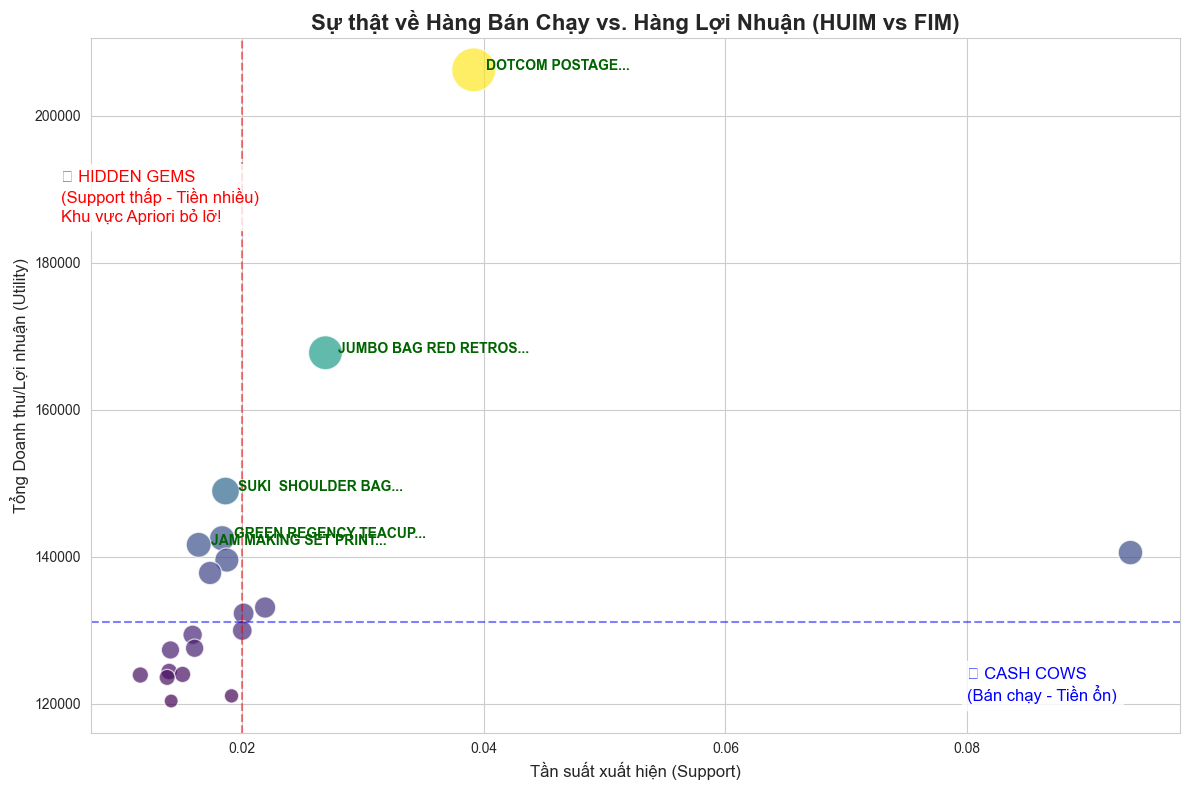

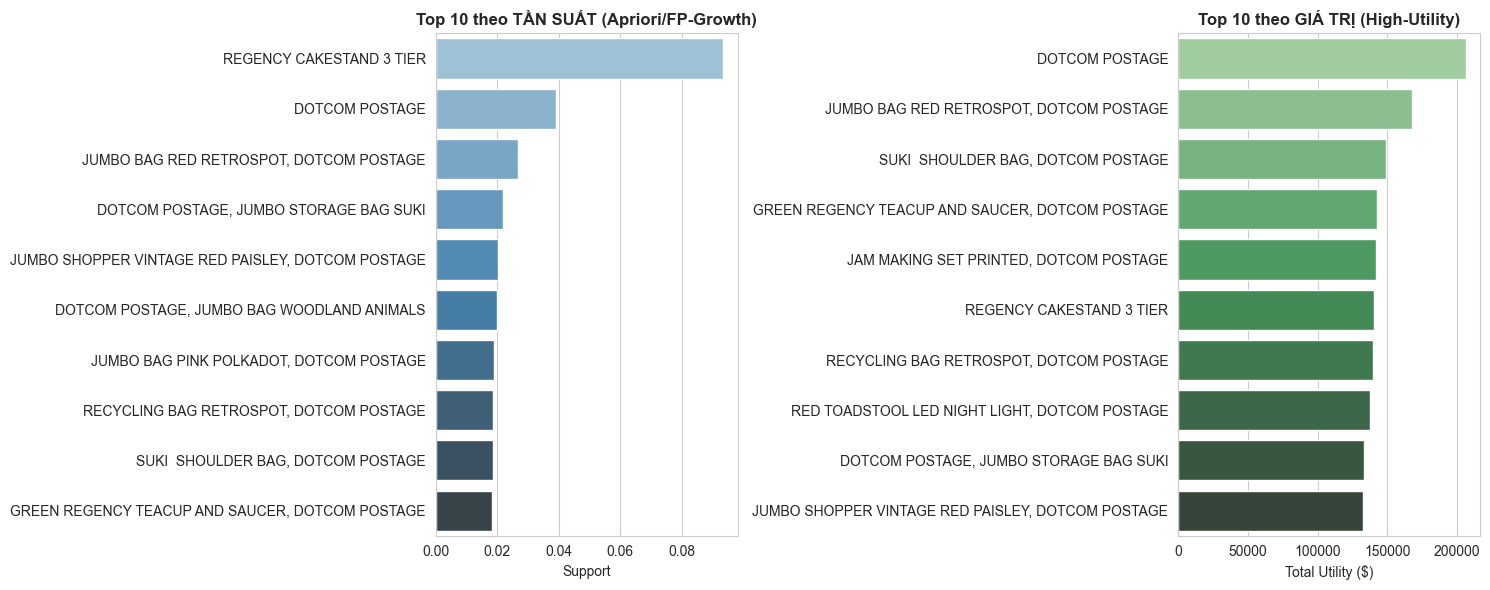

✅ Đã vẽ xong 2 biểu đồ minh họa tư duy!


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Đọc dữ liệu kết quả HUIM bạn vừa tạo
df = pd.read_csv('../data/processed/high_utility_results_manual.csv')

# --- BIỂU ĐỒ 1: SCATTER PLOT (MA TRẬN GIÁ TRỊ) ---
# Mục tiêu: Tìm ra các "Hidden Gems" (Support thấp nhưng Tiền nhiều)

plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Vẽ điểm
scatter = sns.scatterplot(
    data=df, 
    x='Support', 
    y='Utility', 
    size='Utility', 
    hue='Utility',
    sizes=(100, 1000), 
    palette='viridis',
    legend=False,
    alpha=0.7
)

# Chia 4 góc phần tư (Quadrants)
med_sup = df['Support'].median()
med_util = df['Utility'].median()

plt.axvline(x=0.02, color='red', linestyle='--', alpha=0.5, label='Min Support (Apriori 2%)')
plt.axhline(y=med_util, color='blue', linestyle='--', alpha=0.5)

# Gắn nhãn cho các điểm đặc biệt (Top Utility & Top Support)
# Lấy Top 5 Utility
top_util = df.nlargest(5, 'Utility')
# Lấy Top 3 Support (nhưng Utility ko cao nhất)
top_sup = df.nlargest(3, 'Support')

texts = []
for i, row in top_util.iterrows():
    # Chỉ lấy tên sản phẩm đầu tiên trong set cho ngắn gọn
    short_name = row['Itemsets'].split(',')[0][:20] + "..."
    plt.text(row['Support']+0.001, row['Utility'], short_name, fontsize=10, weight='bold', color='darkgreen')

plt.title('Sự thật về Hàng Bán Chạy vs. Hàng Lợi Nhuận (HUIM vs FIM)', fontsize=16, fontweight='bold')
plt.xlabel('Tần suất xuất hiện (Support)', fontsize=12)
plt.ylabel('Tổng Doanh thu/Lợi nhuận (Utility)', fontsize=12)

# Chú thích vùng
plt.text(0.005, df['Utility'].max()*0.9, '💎 HIDDEN GEMS\n(Support thấp - Tiền nhiều)\nKhu vực Apriori bỏ lỡ!', 
         fontsize=12, color='red', bbox=dict(facecolor='white', alpha=0.8))

plt.text(0.08, df['Utility'].min(), '📦 CASH COWS\n(Bán chạy - Tiền ổn)', 
         fontsize=12, color='blue', bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('chart_utility_vs_support.png')
plt.show()

# --- BIỂU ĐỒ 2: SO SÁNH XẾP HẠNG (RANKING SHIFT) ---
# Mục tiêu: So sánh Top 10 sản phẩm theo 2 tư duy khác nhau

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Top 10 theo Support (Tư duy cũ)
top_sup_chart = df.nlargest(10, 'Support')
sns.barplot(ax=axes[0], x='Support', y='Itemsets', data=top_sup_chart, palette='Blues_d')
axes[0].set_title('Top 10 theo TẦN SUẤT (Apriori/FP-Growth)', fontweight='bold')
axes[0].set_xlabel('Support')
axes[0].set_ylabel('')

# Top 10 theo Utility (Tư duy mới)
top_util_chart = df.nlargest(10, 'Utility')
sns.barplot(ax=axes[1], x='Utility', y='Itemsets', data=top_util_chart, palette='Greens_d')
axes[1].set_title('Top 10 theo GIÁ TRỊ (High-Utility)', fontweight='bold')
axes[1].set_xlabel('Total Utility ($)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('chart_ranking_comparison.png')
plt.show()

print("✅ Đã vẽ xong 2 biểu đồ minh họa tư duy!")

In [ ]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
import os
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

# --- 1. Cấu hình đường dẫn và tham số ---
# Sử dụng đường dẫn từ pipeline của Lab
BASKET_PATH = "../data/processed/basket_bool.parquet"
OUTPUT_IMG_DIR = "../images/figures/"
os.makedirs(OUTPUT_IMG_DIR, exist_ok=True)

# Dải tham số min_support để kiểm tra độ nhạy (giảm dần)
# Theo kỳ vọng của Lab: Apriori sẽ chậm đi đáng kể khi support giảm
SUPPORT_LEVELS = [0.02, 0.015, 0.01, 0.008, 0.006] 
MIN_CONFIDENCE = 0.3

# --- 2. Nạp dữ liệu ---
if not os.path.exists(BASKET_PATH):
    print(f"Lỗi: Không tìm thấy {BASKET_PATH}. Hãy chạy notebook basket_preparation trước.")
    exit()

basket_bool = pd.read_parquet(BASKET_PATH)
print(f"Đã nạp dữ liệu: {basket_bool.shape[0]} giao dịch, {basket_bool.shape[1]} sản phẩm.")

# --- 3. Thực hiện thí nghiệm ---
results = []

for sup in SUPPORT_LEVELS:
    print(f"\nĐang thử nghiệm với min_support = {sup}...")
    
    # Đo hiệu năng Apriori
    start_ap = time.time()
    freq_ap = apriori(basket_bool, min_support=sup, use_colnames=True)
    end_ap = time.time() - start_ap
    
    # Đo hiệu năng FP-Growth
    start_fp = time.time()
    freq_fp = fpgrowth(basket_bool, min_support=sup, use_colnames=True)
    end_fp = time.time() - start_fp
    
    # Sinh luật kết hợp để đếm số lượng
    rules = association_rules(freq_fp, metric="confidence", min_threshold=MIN_CONFIDENCE)
    
    # Tính độ dài trung bình của itemset
    avg_len = freq_fp['itemsets'].apply(len).mean() if not freq_fp.empty else 0
    
    results.append({
        'min_support': sup,
        'apriori_time': end_ap,
        'fpgrowth_time': end_fp,
        'num_itemsets': len(freq_fp),
        'num_rules': len(rules),
        'avg_itemset_len': avg_len
    })
    print(f" - Apriori: {end_ap:.2f}s | FP-Growth: {end_fp:.2f}s | Luật: {len(rules)}")

# Chuyển kết quả sang DataFrame
df_res = pd.DataFrame(results)

# --- 4. Trực quan hóa kết quả (Yêu cầu 5.2.3) ---

sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(figsize=(12, 6))

# Biểu đồ 1: Thời gian thực thi (So sánh độ nhạy hiệu năng)
ax1.set_xlabel('Min Support (Giảm dần)')
ax1.set_ylabel('Thời gian chạy (giây)', color='tab:red')
ax1.plot(df_res['min_support'], df_res['apriori_time'], 'o-', color='tab:red', label='Thời gian Apriori', linewidth=2)
ax1.plot(df_res['min_support'], df_res['fpgrowth_time'], 's--', color='tab:orange', label='Thời gian FP-Growth', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.invert_xaxis() # Đảo ngược trục X để thấy xu hướng khi support giảm

# Biểu đồ 2: Số lượng luật sinh ra (Trục phụ)
ax2 = ax1.twinx()
ax2.set_ylabel('Số lượng luật / Tập phổ biến', color='tab:blue')
ax2.bar(df_res['min_support'], df_res['num_rules'], alpha=0.3, color='tab:blue', width=0.001, label='Số lượng luật')
ax2.step(df_res['min_support'], df_res['num_itemsets'], where='mid', color='tab:cyan', label='Số tập phổ biến')
ax2.tick_params(axis='y', labelcolor='tab:blue')

fig.tight_layout()
plt.title('So sánh hiệu năng và Quy mô dữ liệu: Apriori vs FP-Growth', fontsize=15)
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

plt.savefig(os.path.join(OUTPUT_IMG_DIR, 'sensitivity_analysis.png'))
print(f"\nThí nghiệm hoàn tất. Biểu đồ đã lưu tại: {OUTPUT_IMG_DIR}sensitivity_analysis.png")